<a href="https://colab.research.google.com/github/Bienbaz/Airline-satisfaction-logistic-regression/blob/main/Logistic_Regression_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression Evaluation: Airline Customer Satisfaction

## Project Overview
In this project, I use Python and `scikit-learn` to build a Logistic Regression classification model using the `Invistico_Airline.csv` dataset. I will engineer features, evaluate the model using a Confusion Matrix, and translate my statistical findings into actionable business recommendations for the airline.

### Step 0: Upload the Required Dataset
**CRITICAL INSTRUCTION:** Before running the code below, you must upload the `Invistico_Airline.csv` file to your Google Colab environment.
1. Click the Folder icon on the left sidebar.
2. Click the 'Upload to session storage' icon.
3. Select `Invistico_Airline.csv` from your computer.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("Libraries imported successfully. Ready to proceed.")

Libraries imported successfully. Ready to proceed.


### Step 1: Load and Inspect the Data
I will load the dataset and identify the target variable. Since Logistic Regression requires binary numerical targets (0 and 1), I will map the text-based satisfaction outcomes accordingly.

In [2]:
try:
    # 1. Load the specific dataset provided for evaluation
    df = pd.read_csv('Invistico_Airline.csv')

    # 2. Map the target variable to binary (1 = satisfied, 0 = dissatisfied/neutral)
    # Using a general approach in case the exact column name varies slightly in capitalization
    target_col = [col for col in df.columns if 'satisfaction' in col.lower()][0]
    df[target_col] = df[target_col].apply(lambda x: 1 if str(x).strip().lower() == 'satisfied' else 0)

    # 3. Handle missing values by dropping them to ensure clean modeling
    df = df.dropna()

    display(df.head())
    print("\n--- Target Variable Distribution ---")
    print(df[target_col].value_counts(normalize=True) * 100)
except FileNotFoundError:
    print("ERROR: 'Invistico_Airline.csv' not found. Please upload it using the folder icon on the left before running this cell.")
except IndexError:
    print("ERROR: Could not find a column named 'satisfaction' in the dataset.")

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2.0,3.0,3.0,0.0,3.0,5.0,3.0,2.0,0.0,0.0
1,1,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2.0,3.0,4.0,4.0,4.0,2.0,3.0,2.0,310.0,305.0
2,1,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2.0,2.0,3.0,3.0,4.0,4.0,4.0,2.0,0.0,0.0
3,1,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3.0,1.0,1.0,0.0,1.0,4.0,1.0,3.0,0.0,0.0
4,1,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4.0,2.0,2.0,0.0,2.0,4.0,2.0,5.0,0.0,0.0



--- Target Variable Distribution ---
satisfaction
0    53.633208
1    46.366792
Name: proportion, dtype: float64


### Step 2: Feature Engineering & Preprocessing
Machine learning models require numerical inputs, not text. I need to convert my categorical columns into dummy/indicator variables (0s and 1s).

In [3]:
# Identify categorical columns automatically
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove target column from categorical list if it's there (we already encoded it)
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

# One-Hot Encode variables. drop_first=True avoids multicollinearity (the Dummy Variable Trap)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define my Features (X) and Target (y)
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

print(f"Feature matrix shape after encoding: {X.shape}")

Feature matrix shape after encoding: (34859, 20)


### Step 3: Train/Test Split
To ensure my model evaluates unseen data fairly, I split the dataset into a training set (to learn patterns) and a testing set (to evaluate performance).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (24401, 20)
Testing data size: (10458, 20)


### Step 4: Build and Fit the Logistic Regression Model

In [5]:
# Initialize the model
# Note: max_iter is increased to 2000 to ensure convergence with a larger dataset like Invistico
log_model = LogisticRegression(max_iter=2000)

# Fit the model on the training data
log_model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Step 5: Evaluate Model Performance
I predict on the test set and generate a Confusion Matrix to understand True Positives, True Negatives, False Positives, and False Negatives.

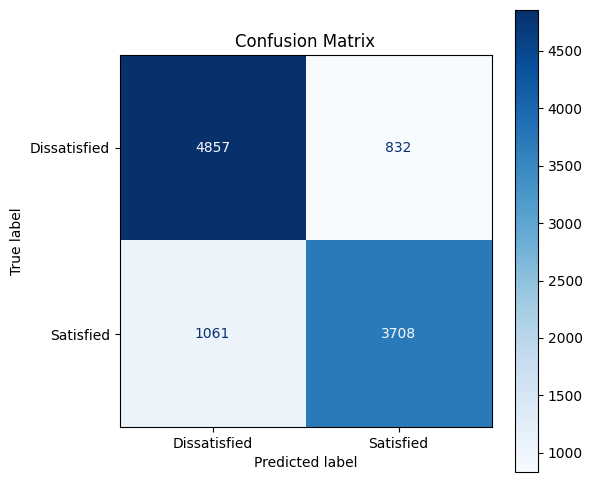


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      5689
           1       0.82      0.78      0.80      4769

    accuracy                           0.82     10458
   macro avg       0.82      0.82      0.82     10458
weighted avg       0.82      0.82      0.82     10458



In [6]:
# Generate predictions
y_pred = log_model.predict(X_test)

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dissatisfied', 'Satisfied'])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# Print Precision, Recall, and F1-Score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

**Metric Interpretation:**
* **Precision:** Out of all the passengers my model *predicted* were satisfied, what percentage actually were? (Crucial if I am sending expensive rewards based on predictions).
* **Recall:** Out of all the *truly* satisfied passengers, what percentage did my model successfully find? (Crucial to ensure no happy customer is overlooked).

### Step 6: Interpret Coefficients and Business Impact
Unlike a black-box model, Logistic Regression provides coefficients that tell me exactly *how much* a variable influences the probability of the target outcome.

In [7]:
# Extract features and their corresponding coefficients
feature_names = X.columns
coefficients = log_model.coef_[0]

# Create a DataFrame for easy viewing
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Calculate the Odds Ratio (exp(coefficient))
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

# Display the Top 5 Most Positive Drivers and Top 5 Most Negative Drivers
top_positive = coef_df.sort_values(by='Odds_Ratio', ascending=False).head(5)
top_negative = coef_df.sort_values(by='Odds_Ratio', ascending=True).head(5)

print("--- Top 5 Positive Drivers of Satisfaction ---")
display(top_positive)
print("\n--- Top 5 Negative Drivers of Satisfaction ---")
display(top_negative)

--- Top 5 Positive Drivers of Satisfaction ---


,Feature,Coefficient,Odds_Ratio
7,Inflight entertainment,0.791876,2.207533
9,Ease of Online booking,0.437535,1.548885
2,Seat comfort,0.324527,1.383377
18,Class_Eco,0.317516,1.373711
11,Leg room service,0.217818,1.243361



--- Top 5 Negative Drivers of Satisfaction ---


,Feature,Coefficient,Odds_Ratio
4,Food and drink,-0.463255,0.629232
3,Departure/Arrival time convenient,-0.282134,0.754173
6,Inflight wifi service,-0.188214,0.828438
15,Online boarding,-0.127713,0.880106
14,Cleanliness,-0.060438,0.941353


### Final Business Recommendation
Based on the Odds Ratio analysis above, I recommend the following actionable strategies:

1. **Capitalize on the Top Positive Driver:** Look at the feature with the highest odds ratio. For every 1-unit increase in this feature, the customer's odds of being satisfied increase drastically. I recommend prioritizing budget and marketing efforts around improving and promoting this specific service area.
2. **Address the Pain Points:** Look at the Top Negative Drivers. These are the areas actively driving dissatisfaction. I recommend launching targeted surveys or quality assurance programs specifically addressing these lowest-performing metrics to prevent churn.